In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [86]:
def analytical_solution(x, t, k, epsilon, w_r, w_i, r, phi):
    return -2 * epsilon / k * r * np.exp(w_i * t) * np.cos(w_r * t - phi) * np.sin(k * x)

def E_analytical(t, k, epsilon, w_r, w_i, r):
    x = np.linspace(0, 4 * np.pi / k, 10_000)
    ana = analytical_solution(x, t, k, epsilon, w_r, w_i, r, 0.0)
    return np.sqrt(np.trapz(ana**2, x))

In [87]:
closures = [
    "Gram",
    "ExtGram",
    "Grad"
]
T_end = 15.0
M_vec = [6, 7]

x_lower = 0.0; x_upper = 12.566370614359172
base_tree_level = 6
polydeg = 3

epsilon = 0.001
k = [0.5]#!, 0.4, 0.3, 0.2]
w_r = [1.4156, 1.2850, 1.1598, 1.0640]
w_i = [-0.1533, -0.0661, -0.0126, -5.51e-5]
r = [0.3677, 0.4247, 0.6368, 1.1297]
phi = [0.5362, 0.3358, 0.1143, 0.0013]

M=6, k=0.5: w_r=1.4156, w_i=-0.1533, r=0.3677, phi=0.5362


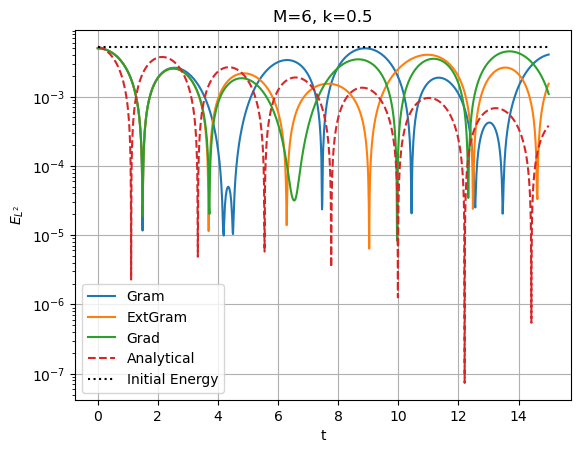

M=7, k=0.5: w_r=1.4156, w_i=-0.1533, r=0.3677, phi=0.5362


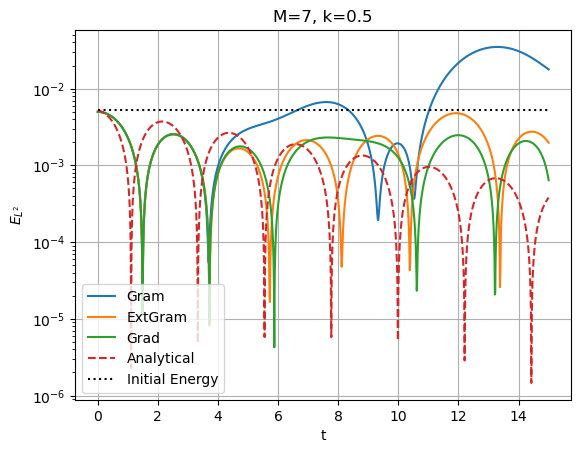

In [88]:
Error = {}
for M in M_vec:
    for k_ in k:
        i = k.index(k_)
        w_r_ = w_r[i]
        w_i_ = w_i[i]
        r_ = r[i]
        phi_ = phi[i]
        print(f"M={M}, k={k_}: w_r={w_r_}, w_i={w_i_}, r={r_}, phi={phi_}")

        plt.figure()
        for closure in closures:
            file = f"../out/VlasovPoisson/energy_moments_closure{closure}_T{T_end}_M{M}_k{k_}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
            data = pd.read_csv(file)

            plt.plot(data["time"], data["E_L2"], label=closure)
        
            # Analytical solution
            E_L2_ana = [E_analytical(t, k_, epsilon, w_r_, w_i_, r_) for t in data["time"]]

            # Compute relative L2-error
            E_num = data["E_L2"].to_numpy()
            E_rel_L2 = np.linalg.norm(E_num - np.array(E_L2_ana)) / np.linalg.norm(E_L2_ana)
            Error[(closure, M, k_)] = E_rel_L2

        plt.plot(data["time"], E_L2_ana, "--", label="Analytical")
        plt.hlines(y=E_L2_ana[0], xmin=data["time"].min(), xmax=data["time"].max(), color='k', linestyle=':', label="Initial Energy")
        plt.yscale("log")
        plt.xlabel("t")
        plt.ylabel("$E_{L^2}$")
        plt.title(f"M={M}, k={k_}")
        plt.legend(loc='lower left')
        plt.grid()
        plt.savefig(f"../out/VlasovPoisson/LandauDamping_M{M}_k{k_}_epsilon{epsilon}_p{polydeg}.pdf")
        plt.show()

M=6, k=0.5: w_r=1.4156, w_i=-0.1533, r=0.3677, phi=0.5362
M=6, k=0.4: w_r=1.285, w_i=-0.0661, r=0.4247, phi=0.3358
M=6, k=0.3: w_r=1.1598, w_i=-0.0126, r=0.6368, phi=0.1143
M=6, k=0.2: w_r=1.064, w_i=-5.51e-05, r=1.1297, phi=0.0013


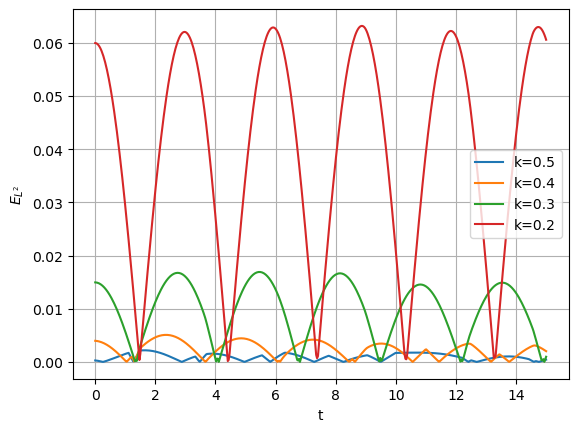

In [89]:
k = [0.5, 0.4, 0.3, 0.2]
polydeg = 1
M_vec = [6]
closure = "ExtGram"
for M in M_vec:
    plt.figure()
    for k_ in k:
        i = k.index(k_)
        w_r_ = w_r[i]
        w_i_ = w_i[i]
        r_ = r[i]
        phi_ = phi[i]
        print(f"M={M}, k={k_}: w_r={w_r_}, w_i={w_i_}, r={r_}, phi={phi_}")

        file = f"../out/VlasovPoisson/energy_moments_closure{closure}_T{T_end}_M{M}_k{k_}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
        data = pd.read_csv(file)
    
        # Analytical solution
        E_L2_ana = [E_analytical(t, k_, epsilon, w_r_, w_i_, r_) for t in data["time"]]

        plt.plot(data["time"], np.abs(data["E_L2"] - E_L2_ana), label=f"k={k_}")

    # plt.yscale("log")
    plt.xlabel("t")
    plt.ylabel("$E_{L^2}$")
    plt.legend(loc='best')
    plt.grid()
    plt.savefig(f"../out/VlasovPoisson/LandauDamping_Error_M{M}_closure{closure}_epsilon{epsilon}_p{polydeg}.pdf")
    plt.show()

In [90]:
# for M in M_vec:
#     plt.figure()
#     for closure in closures:
#         errors = [Error[(closure, M, k_)] for k_ in k]
#         plt.semilogy(k[:2], errors, marker='o', label=closure)

#     plt.xticks(k[:2])
#     plt.xlabel("k")
#     plt.ylabel("Relative $L^2$-error of $E_{L^2}$")
#     plt.title(f"M={M}")
#     plt.legend()
#     plt.grid()
#     plt.show()

In [91]:
# for k_ in k:
#     plt.figure()
#     for closure in closures:
#         errors = [Error[(closure, M, k_)] for M in M_vec]
#         plt.semilogy(M_vec, errors, marker='o', label=closure)

#     plt.xticks(M_vec)
#     plt.xlabel("M")
#     plt.ylabel("Relative $L^2$-error of $E_{L^2}$")
#     plt.title(f"k={k_}")
#     plt.legend()
#     plt.grid()
#     plt.show()